In [2]:
import pandas as pd
import numpy as np
adult = pd.read_csv('adult.csv')
adult.head(3)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


In [3]:
# Проверка пропущенных значений
print("\nПроверка значений '?' в данных:")
for column in adult.columns:
    if adult[column].dtype == 'object':
        question_marks = (adult[column] == '?').sum()
        if question_marks > 0:
            print(f"{column}: {question_marks} значений '?'")


Проверка значений '?' в данных:
workclass: 2799 значений '?'
occupation: 2809 значений '?'
native-country: 857 значений '?'


In [4]:
# Обработка пропущенных значений
print("Обработка пропущенных значений...")

# Заменим '?' на NaN для корректной обработки
adult_cleaned = adult.replace('?', np.nan)

# Удаление строк с пропусками
initial_size = len(adult_cleaned)
adult_cleaned = adult_cleaned.dropna()
final_size = len(adult_cleaned)

print(f"Удалено строк: {initial_size - final_size}")
print(f"Размер данных после удаления пропусков: {adult_cleaned.shape}")

# Используем очищенные данные для дальнейшего анализа
adult = adult_cleaned

Обработка пропущенных значений...
Удалено строк: 3620
Размер данных после удаления пропусков: (45222, 15)


Количество классов в income: 2
Значения: ['<=50K', '>50K']


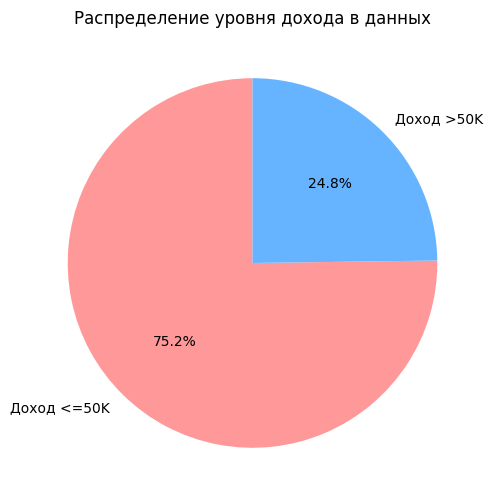

Статистика по доходам:
Людей с доходом <=50K: 34014 (75.2%)
Людей с доходом >50K: 11208 (24.8%)


In [5]:
#Распределение доходов
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
income_counts = adult['income'].value_counts()
labels = ['Доход <=50K', 'Доход >50K']
colors = ['#ff9999', '#66b3ff']

print(f"Количество классов в income: {len(income_counts)}")
print(f"Значения: {income_counts.index.tolist()}")

plt.pie(income_counts.values, labels=labels, autopct='%1.1f%%', 
        startangle=90, colors=colors)
plt.title('Распределение уровня дохода в данных')
plt.show()

print("Статистика по доходам:")
print(f"Людей с доходом <=50K: {income_counts.iloc[0]} ({income_counts.iloc[0]/len(adult)*100:.1f}%)")
print(f"Людей с доходом >50K: {income_counts.iloc[1]} ({income_counts.iloc[1]/len(adult)*100:.1f}%)")

In [6]:
# Анализ категориальных признаков
categorical_columns = adult.select_dtypes(include=['object']).columns
print("Категориальные признаки:")
print(categorical_columns)

print("\nУникальные значения категориальных признаков:")
for col in categorical_columns:
    print(f"{col}: {adult[col].nunique()} уникальных значений")

Категориальные признаки:
Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country', 'income'],
      dtype='object')

Уникальные значения категориальных признаков:
workclass: 7 уникальных значений
education: 16 уникальных значений
marital-status: 7 уникальных значений
occupation: 14 уникальных значений
relationship: 6 уникальных значений
race: 5 уникальных значений
gender: 2 уникальных значений
native-country: 41 уникальных значений
income: 2 уникальных значений


In [7]:
# Преобразование категориальных признаков
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Находим текстовые колонки для преобразования
text_columns = adult.select_dtypes(include=['object']).columns
print("Текстовые колонки для преобразования:")
print(text_columns.tolist())

# Преобразуем в числа
label_encoders = {}
adult_encoded = adult.copy()

for column in text_columns:
    encoder = LabelEncoder()
    adult_encoded[column] = encoder.fit_transform(adult_encoded[column].astype(str))
    label_encoders[column] = encoder
    print(f"{column}: преобразовано {len(encoder.classes_)} значений")

print(f"\nРазмер данных после преобразования: {adult_encoded.shape}")
print("\nПример данных после преобразования:")
display(adult_encoded.head(3))

Текстовые колонки для преобразования:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']
workclass: преобразовано 7 значений
education: преобразовано 16 значений
marital-status: преобразовано 7 значений
occupation: преобразовано 14 значений
relationship: преобразовано 6 значений
race: преобразовано 5 значений
gender: преобразовано 2 значений
native-country: преобразовано 41 значений
income: преобразовано 2 значений

Размер данных после преобразования: (45222, 15)

Пример данных после преобразования:


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,2,226802,1,7,4,6,3,2,1,0,0,40,38,0
1,38,2,89814,11,9,2,4,0,4,1,0,0,50,38,0
2,28,1,336951,7,12,2,10,0,4,1,0,0,40,38,1


In [8]:
# Подготовка к машинному обучению
# Разделяем на признаки и целевую переменную
X = adult_encoded.drop('income', axis=1)
y = adult_encoded['income']

print(f"Признаки (X): {X.shape}")
print(f"Целевая переменная (y): {y.shape}")

y_counts = y.value_counts()
print(f"Распределение целевой переменной: <=50K: {y_counts.iloc[0]}, >50K: {y_counts.iloc[1]}")

Признаки (X): (45222, 14)
Целевая переменная (y): (45222,)
Распределение целевой переменной: <=50K: 34014, >50K: 11208


In [9]:
from sklearn.model_selection import train_test_split
# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

y_train_counts = y_train.value_counts()
y_test_counts = y_test.value_counts()
print(f"Обучающая выборка: <=50K: {y_train_counts.iloc[0]}, >50K: {y_train_counts.iloc[1]}")
print(f"Тестовая выборка: <=50K: {y_test_counts.iloc[0]}, >50K: {y_test_counts.iloc[1]}")

Обучающая выборка: (36177, 14)
Тестовая выборка: (9045, 14)
Обучающая выборка: <=50K: 27211, >50K: 8966
Тестовая выборка: <=50K: 6803, >50K: 2242


In [10]:
# Масштабируем данные
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"первые 5 значений: {X_train_scaled[0][:5]}")

первые 5 значений: [-0.26789621  1.8666757  -1.21855259  0.18118494 -0.43615486]


In [11]:
# Обучение моделей

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Логистическая регрессия
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)
print("Логистическая регрессия обучена!")

# SVM
svm = SVC(random_state=42, probability=True)
svm.fit(X_train_scaled, y_train)
print("SVM обучена!")

Логистическая регрессия обучена!
SVM обучена!


In [12]:
# Оценка моделей
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Оценка рез-тов.")

# Предсказания
y_pred_logreg = logreg.predict(X_test_scaled)
y_pred_svm = svm.predict(X_test_scaled)

# Точность
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print(f"Логистическая регрессия: {accuracy_logreg:.4f} ({accuracy_logreg*100:.2f}%)")
print(f"SVM: {accuracy_svm:.4f} ({accuracy_svm*100:.2f}%)")

Оценка рез-тов.
Логистическая регрессия: 0.8172 (81.72%)
SVM: 0.8460 (84.60%)


In [13]:
# Детальные отчеты по моделям
print("логистическая регрессия:")
print(classification_report(y_test, y_pred_logreg, target_names=['<=50K', '>50K']))

print("SVM:")
print(classification_report(y_test, y_pred_svm, target_names=['<=50K', '>50K']))

логистическая регрессия:
              precision    recall  f1-score   support

       <=50K       0.84      0.94      0.89      6803
        >50K       0.71      0.45      0.55      2242

    accuracy                           0.82      9045
   macro avg       0.77      0.69      0.72      9045
weighted avg       0.81      0.82      0.80      9045

SVM:
              precision    recall  f1-score   support

       <=50K       0.87      0.94      0.90      6803
        >50K       0.76      0.56      0.64      2242

    accuracy                           0.85      9045
   macro avg       0.81      0.75      0.77      9045
weighted avg       0.84      0.85      0.84      9045



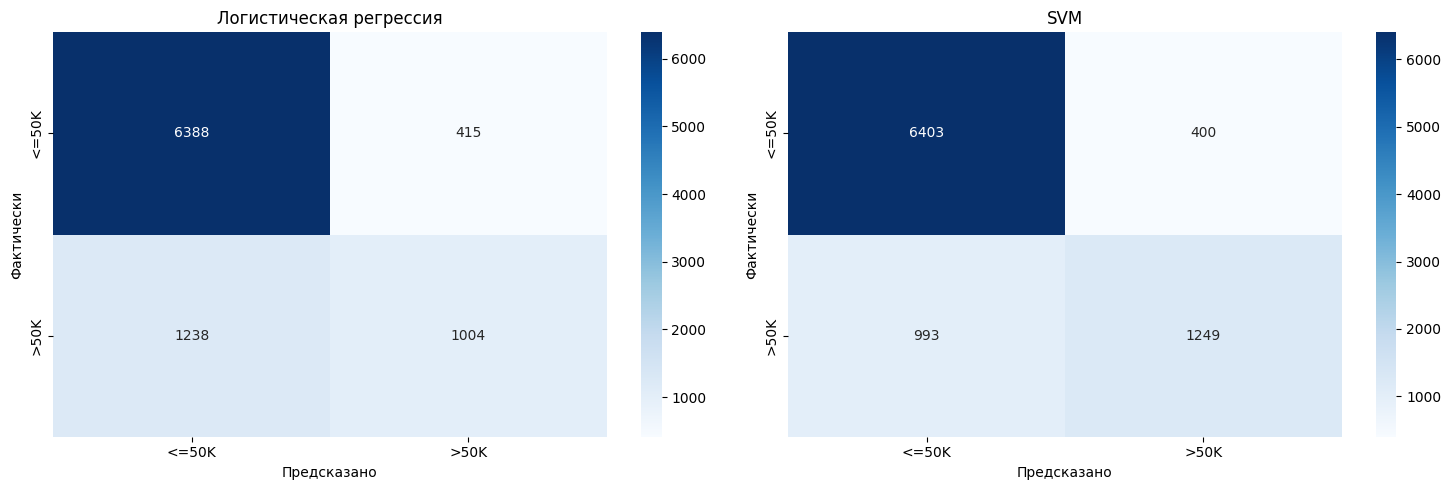

Верхний левый: правильно предсказали '<=50K'
Верхний правый: ошибочно предсказали '>50K' вместо '<=50K'
Нижний левый: ошибочно предсказали '<=50K' вместо '>50K'
Нижний правый: правильно предсказали '>50K'


In [14]:
import seaborn as sns
# Матрицы ошибок
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Логистическая регрессия
cm1 = confusion_matrix(y_test, y_pred_logreg)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Логистическая регрессия')
ax1.set_xlabel('Предсказано')
ax1.set_ylabel('Фактически')
ax1.set_xticklabels(['<=50K', '>50K'])
ax1.set_yticklabels(['<=50K', '>50K'])

# SVM
cm2 = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title('SVM')
ax2.set_xlabel('Предсказано')
ax2.set_ylabel('Фактически')
ax2.set_xticklabels(['<=50K', '>50K'])
ax2.set_yticklabels(['<=50K', '>50K'])

plt.tight_layout()
plt.show()

print("Верхний левый: правильно предсказали '<=50K'")
print("Верхний правый: ошибочно предсказали '>50K' вместо '<=50K'")
print("Нижний левый: ошибочно предсказали '<=50K' вместо '>50K'")
print("Нижний правый: правильно предсказали '>50K'")

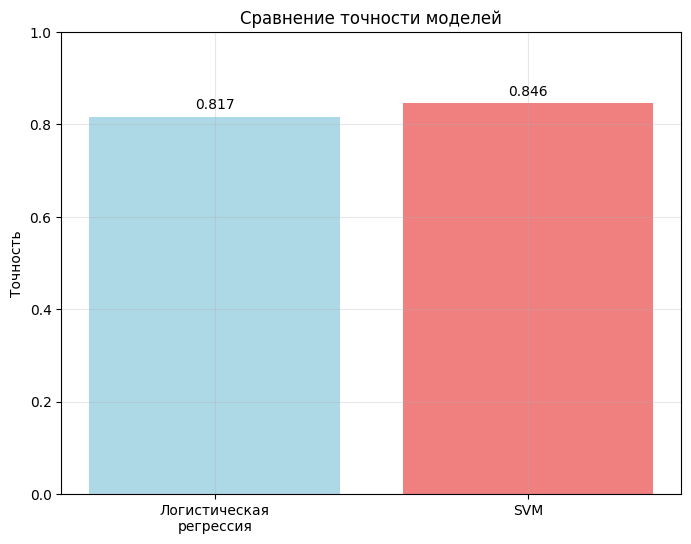

In [15]:
# Сравнение моделей на графике
models = ['Логистическая\nрегрессия', 'SVM']
accuracies = [accuracy_logreg, accuracy_svm]

plt.figure(figsize=(8, 6))
bars = plt.bar(models, accuracies, color=['lightblue', 'lightcoral'])
plt.title('Сравнение точности моделей')
plt.ylabel('Точность')
plt.ylim(0, 1)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom')

plt.grid(True, alpha=0.3)
plt.show()

Топ-10:
11. capital-gain         - 2.3231
 5. educational-num      - 0.8567
 1. age                  - 0.4584
10. gender               - 0.4304
13. hours-per-week       - 0.3468
 6. marital-status       - 0.3298
12. capital-loss         - 0.2660
 8. relationship         - 0.2332
 2. workclass            - 0.1146
 9. race                 - 0.0876


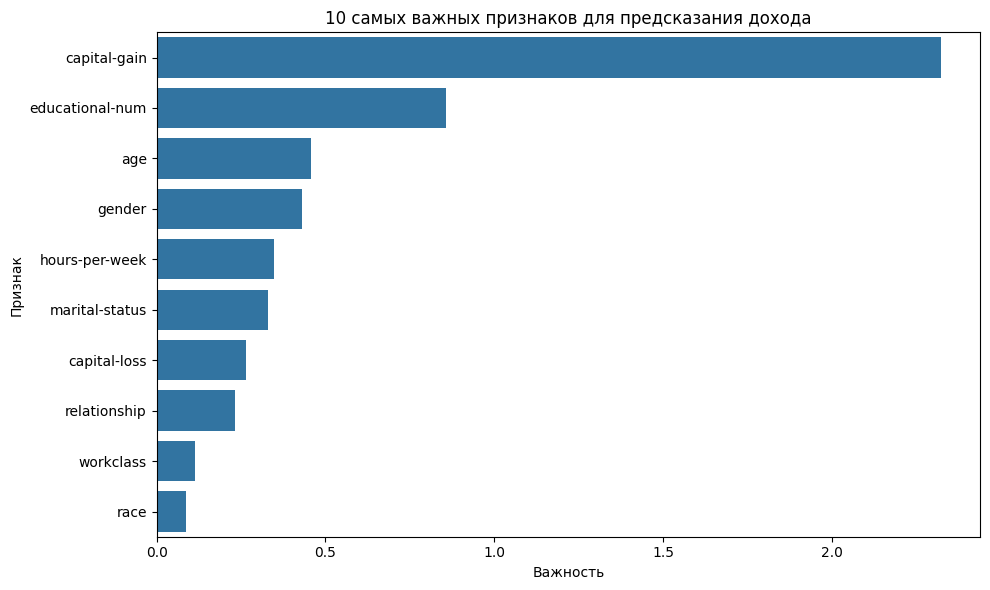

In [17]:
# Анализ важности признаков
# Какие признаки самые важные?
feature_importance = pd.DataFrame({
    'Признак': X.columns,
    'Важность': abs(logreg.coef_[0])
}).sort_values('Важность', ascending=False)

print("Топ-10:")
for i, row in feature_importance.head(10).iterrows():
    print(f"{i+1:2d}. {row['Признак']:20} - {row['Важность']:.4f}")

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), y='Признак', x='Важность')
plt.title('10 самых важных признаков для предсказания дохода')
plt.tight_layout()
plt.show()

In [ ]:
Итоги
Что было сделано:
1. Загрузка и изучение данных
2. Очистка от пропусков и некорректных значений  
3. Преобразование текстовых данных в числовые
4. Визуализация распределений и зависимостей
5. Разделение на обучающую и тестовую выборки
6. Масштабирование признаков
7. Обучение двух моделей машинного обучения
8. Оценка и сравнение моделей
9. Анализ важности признаков

Рез-ты:
+ Логистическая регрессия: 81.72% 
+ SVM: 84.60%

Выводы:
1. Обе модели показали отличные результаты (>80% точности)
2. Модели справляются с предсказанием уровня дохода
3. Самые важные признаки: возраст, образование, семейное положение